# 데이터 불러오기 - 판매금액순 TOP 50 상품 리뷰 분석

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

# 데이터 불러오기
df_merged = pd.read_csv("reviews_merged.csv", encoding="utf-8-sig")

# 1. 상위 데이터 확인
print("👀 통합 데이터 상위 5개 확인")
display(df_merged.head())

# 2. 데이터 요약 정보 (컬럼명, 데이터 개수, 타입 확인)
print("\n📊 데이터 요약 정보")
df_merged.info()

# 3. 결측치 확인
print("\n🚨 결측치 확인")
print(df_merged.isnull().sum())

👀 통합 데이터 상위 5개 확인


,goods_no,review_no,content,grade,option_size,size_feedback,create_date,review_sex,height,weight,...,month,bmi,size_type,content_clean,goods_name,sale_price,sale_rate,review_count,review_score,category
0,6092190,83820239,아이가 입울거라서 사이즈 때문에 매장에서 입어보고 샀어요! \n이 계절에 딱 필요한...,5,04.화이트 · S,정사이즈,2026-04-20 10:14:21+09:00,여성,152.0,45.0,...,4,19.5,문자형,아이가 입울거라서 사이즈 때문에 매장에서 입어보고 샀어요 이 계절에 딱 필요한 필수...,[한소희 PICK] [UV 프로텍션] 우먼즈 시어 윈드브레이커 (5 colors),55900,0,140,98,아우터
1,6092190,83817463,색상이 너무 고급스럽고 예뻐요 맘에 들어서 좋아요 잘입을께요,5,02.클라우디 블루 · M,조금 큼,2026-04-20 05:44:20+09:00,여성,162.0,65.0,...,4,24.8,문자형,색상이 너무 고급스럽고 예뻐요 맘에 들어서 좋아요 잘입을께요,[한소희 PICK] [UV 프로텍션] 우먼즈 시어 윈드브레이커 (5 colors),55900,0,140,98,아우터
2,6092190,83817336,착용감이 좋습니다.\n재질이 부드럽고 주머니지퍼 모자 허리에 스트링이 있어\n편리합니다.,5,02.클라우디 블루 · L,조금 큼,2026-04-20 04:48:00+09:00,여성,165.0,62.0,...,4,22.8,문자형,착용감이 좋습니다 재질이 부드럽고 주머니지퍼 모자 허리에 스트링이 있어 편리합니다,[한소희 PICK] [UV 프로텍션] 우먼즈 시어 윈드브레이커 (5 colors),55900,0,140,98,아우터
3,6092190,83817326,부드럽고 주머니지퍼 모자 허리에 스트링이 있어\n편리합니다.,5,02.클라우디 블루 · L,조금 큼,2026-04-20 04:47:04+09:00,여성,165.0,62.0,...,4,22.8,문자형,부드럽고 주머니지퍼 모자 허리에 스트링이 있어 편리합니다,[한소희 PICK] [UV 프로텍션] 우먼즈 시어 윈드브레이커 (5 colors),55900,0,140,98,아우터
4,6092190,83817305,허리랑 모자에 스트링이 있어서 좋았고~\n재질이 매우 부드러워요~,5,03.라이트 그레이 · L,조금 큼,2026-04-20 04:44:23+09:00,여성,165.0,62.0,...,4,22.8,문자형,허리랑 모자에 스트링이 있어서 좋았고 재질이 매우 부드러워요,[한소희 PICK] [UV 프로텍션] 우먼즈 시어 윈드브레이커 (5 colors),55900,0,140,98,아우터



📊 데이터 요약 정보
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26913 entries, 0 to 26912
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   goods_no       26913 non-null  int64  
 1   review_no      26913 non-null  int64  
 2   content        26913 non-null  object 
 3   grade          26913 non-null  int64  
 4   option_size    26913 non-null  object 
 5   size_feedback  7222 non-null   object 
 6   create_date    26913 non-null  object 
 7   review_sex     24129 non-null  object 
 8   height         24115 non-null  float64
 9   weight         24093 non-null  float64
 10  color          4426 non-null   object 
 11  size           26913 non-null  object 
 12  has_grade      26913 non-null  bool   
 13  year           26913 non-null  int64  
 14  month          26913 non-null  int64  
 15  bmi            24003 non-null  float64
 16  size_type      26913 non-null  object 
 17  content_clean  26913 non-null  object

In [3]:
# 텍스트가 '...'으로 잘리지 않게 설정
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

# 데이터 로드 및 상위 2개 확인
display(df_merged.head(2))

,goods_no,review_no,content,grade,option_size,size_feedback,create_date,review_sex,height,weight,color,size,has_grade,year,month,bmi,size_type,content_clean,goods_name,sale_price,sale_rate,review_count,review_score,category
0,6092190,83820239,아이가 입울거라서 사이즈 때문에 매장에서 입어보고 샀어요! \n이 계절에 딱 필요한 필수템이예요\n화이트가 젤 맘에들었는데 여기저기 휘뚜루 마뚜루 잘어울리네요,5,04.화이트 · S,정사이즈,2026-04-20 10:14:21+09:00,여성,152.0,45.0,화이트,S,True,2026,4,19.5,문자형,아이가 입울거라서 사이즈 때문에 매장에서 입어보고 샀어요 이 계절에 딱 필요한 필수템이예요 화이트가 젤 맘에들었는데 여기저기 휘뚜루 마뚜루 잘어울리네요,[한소희 PICK] [UV 프로텍션] 우먼즈 시어 윈드브레이커 (5 colors),55900,0,140,98,아우터
1,6092190,83817463,색상이 너무 고급스럽고 예뻐요 맘에 들어서 좋아요 잘입을께요,5,02.클라우디 블루 · M,조금 큼,2026-04-20 05:44:20+09:00,여성,162.0,65.0,클라우디 블루,M,True,2026,4,24.8,문자형,색상이 너무 고급스럽고 예뻐요 맘에 들어서 좋아요 잘입을께요,[한소희 PICK] [UV 프로텍션] 우먼즈 시어 윈드브레이커 (5 colors),55900,0,140,98,아우터


In [4]:
# 1. 불필요한 컬럼 리스트 정의
columns_to_drop = [
    'review_sex',   # 우먼즈 브랜드라 의미 없음
    'option_size',  # 이미 size와 color로 분리됨
    'create_date',  # 이미 year와 month로 분리됨
    'content',      # content_clean으로 대체
]

# 2. 컬럼 삭제
df_clean = df_merged.drop(columns=columns_to_drop)

# 3. 정리된 데이터 확인
print("✨ 완료된 데이터 구조:")
df_clean.info()

display(df_clean.head(3))

✨ 완료된 데이터 구조:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26913 entries, 0 to 26912
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   goods_no       26913 non-null  int64  
 1   review_no      26913 non-null  int64  
 2   grade          26913 non-null  int64  
 3   size_feedback  7222 non-null   object 
 4   height         24115 non-null  float64
 5   weight         24093 non-null  float64
 6   color          4426 non-null   object 
 7   size           26913 non-null  object 
 8   has_grade      26913 non-null  bool   
 9   year           26913 non-null  int64  
 10  month          26913 non-null  int64  
 11  bmi            24003 non-null  float64
 12  size_type      26913 non-null  object 
 13  content_clean  26913 non-null  object 
 14  goods_name     26913 non-null  object 
 15  sale_price     26913 non-null  int64  
 16  sale_rate      26913 non-null  int64  
 17  review_count   26913 non-null  int64

,goods_no,review_no,grade,size_feedback,height,weight,color,size,has_grade,year,month,bmi,size_type,content_clean,goods_name,sale_price,sale_rate,review_count,review_score,category
0,6092190,83820239,5,정사이즈,152.0,45.0,화이트,S,True,2026,4,19.5,문자형,아이가 입울거라서 사이즈 때문에 매장에서 입어보고 샀어요 이 계절에 딱 필요한 필수템이예요 화이트가 젤 맘에들었는데 여기저기 휘뚜루 마뚜루 잘어울리네요,[한소희 PICK] [UV 프로텍션] 우먼즈 시어 윈드브레이커 (5 colors),55900,0,140,98,아우터
1,6092190,83817463,5,조금 큼,162.0,65.0,클라우디 블루,M,True,2026,4,24.8,문자형,색상이 너무 고급스럽고 예뻐요 맘에 들어서 좋아요 잘입을께요,[한소희 PICK] [UV 프로텍션] 우먼즈 시어 윈드브레이커 (5 colors),55900,0,140,98,아우터
2,6092190,83817336,5,조금 큼,165.0,62.0,클라우디 블루,L,True,2026,4,22.8,문자형,착용감이 좋습니다 재질이 부드럽고 주머니지퍼 모자 허리에 스트링이 있어 편리합니다,[한소희 PICK] [UV 프로텍션] 우먼즈 시어 윈드브레이커 (5 colors),55900,0,140,98,아우터


# 감성 분석(Sentiment Analysis)

In [5]:
from transformers import pipeline
import torch
import time

# 텍스트 안 잘리게 보기 옵션 (혹시 풀렸을까 봐 다시 적용)
pd.set_option('display.max_colwidth', None)

# 1. GPU 장치 세팅 (RTX 3070 Ti 가동!)
device = 0 if torch.cuda.is_available() else -1

print("✅ 훈련된 실전 감성 분석 전문가 모델 로딩 중...")
sentiment_analyzer = pipeline(
    "text-classification", 
    model="matthewburke/korean_sentiment", 
    device=device
)

print("🚀 df_clean 데이터로 터보 엔진 감성 분석 시작...")
start_time = time.time()

# 2. 💡 핵심: 'content_clean' 컬럼 사용! 
# 혹시 모를 빈칸(NaN)은 빈 문자열로 처리
texts = df_clean['content_clean'].fillna("").astype(str).tolist()

# 3. 배치 처리로 고속 분석
results = sentiment_analyzer(texts, batch_size=64, truncation=True)

# 4. 모델의 결과값을 1(긍정)과 0(부정)으로 치환하여 새로운 컬럼 생성
df_clean['sentiment_confidence'] = [r['score'] for r in results]
df_clean['sentiment_score'] = [1 if res['label'] == 'LABEL_1' else 0 for res in results]

end_time = time.time()
print(f"✅ 감성 분석 완료! 소요 시간: {round((end_time - start_time) / 60, 2)}분")

✅ 훈련된 실전 감성 분석 전문가 모델 로딩 중...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: matthewburke/korean_sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
electra.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🚀 df_clean 데이터로 터보 엔진 감성 분석 시작...
✅ 감성 분석 완료! 소요 시간: 0.85분


In [6]:
# 5. 결과 확인
print("\n👀 깔끔해진 텍스트와 감성 점수 찰떡궁합 확인하기")
display(df_clean[['content_clean', 'sentiment_score', 'sentiment_confidence', 'grade']].head(10))

# 6. 전체 데이터 중 긍정(1)과 부정(0) 통계 확인
print("\n📊 전체 긍정/부정 비율")
print(df_clean['sentiment_score'].value_counts())


👀 깔끔해진 텍스트와 감성 점수 찰떡궁합 확인하기


,content_clean,sentiment_score,sentiment_confidence,grade
0,아이가 입울거라서 사이즈 때문에 매장에서 입어보고 샀어요 이 계절에 딱 필요한 필수템이예요 화이트가 젤 맘에들었는데 여기저기 휘뚜루 마뚜루 잘어울리네요,1,0.971120,5
1,색상이 너무 고급스럽고 예뻐요 맘에 들어서 좋아요 잘입을께요,1,0.973997,5
2,착용감이 좋습니다 재질이 부드럽고 주머니지퍼 모자 허리에 스트링이 있어 편리합니다,1,0.966280,5
3,부드럽고 주머니지퍼 모자 허리에 스트링이 있어 편리합니다,1,0.962447,5
4,허리랑 모자에 스트링이 있어서 좋았고 재질이 매우 부드러워요,1,0.971701,5
5,더운날 입었을때 땀때문에 늘어붙지않은점이 괜찮았어요 끈적라게 안붙는거 좋아요,1,0.967607,5
6,음 생각보다 얇고 나쁘지않아요 근데 나일론이라고 해서 생활방수 된다고 했는데 김치국물은 흡수해버림 ㅠ,1,0.620964,5
7,매장에서 입어보고 샀눈데 역시나 색상도 예쁘고 사이즈도 딱입니당 ㅎㅎ,1,0.972981,5
8,가벼운데 바람막이 기능 좋네요 자주 손가요 다른컬러도 사야지,1,0.971271,5
9,바람막이는 이제 무조건 uv 프로텍션 필수 입니다 자외선 차단이 50 다 그럼 썬크림 안 발라도 되죠 이건 전국민 한 벌씩 무조건 있어야 합니다,1,0.864220,5



📊 전체 긍정/부정 비율
sentiment_score
1    25604
0     1309
Name: count, dtype: int64


In [7]:
# 1. 감성 점수가 0(부정)인 데이터만 골라내기
df_negative = df_clean[df_clean['sentiment_score'] == 0]

print("🚨 1. 모델이 '부정(0)'으로 판단한 전체 리뷰 상위 10개")
display(df_negative[['content_clean', 'sentiment_score', 'sentiment_confidence', 'grade']].head(10))

print("=" * 80)

# 2. 💡 [핵심 인사이트] 별점은 4~5점인데, 텍스트는 부정(0)인 '불일치(Mismatch)' 데이터 찾기
df_mismatch = df_clean[(df_clean['grade'] >= 4) & (df_clean['sentiment_score'] == 0)]

print("💎 2. [진짜 페인포인트] 평점은 높지만 텍스트에 불만이 숨겨진 리뷰 상위 10개")
display(df_mismatch[['content_clean', 'sentiment_score', 'sentiment_confidence', 'grade']].head(10))

print("=" * 80)

# 통계 요약
print(f"📊 전체 부정(0) 리뷰 개수: {len(df_negative)}개")
print(f"🔥 그 중 별점이 높은(4~5점) 숨은 불만 리뷰 개수: {len(df_mismatch)}개")

🚨 1. 모델이 '부정(0)'으로 판단한 전체 리뷰 상위 10개


,content_clean,sentiment_score,sentiment_confidence,grade
18,유브이 기능 있어서 럭저럭 입으려고 하는데 크롭 기장임 키 169인데 참고하세요,0,0.763053,3
92,얇은 바람막이 찾아서 구매했어요 이게 입은건지 의심스러울 정도로 얇아요 사이즈가 s m l 매장에서 입어봤는데 차이가 크지 않았어요 잘입을게요,0,0.581839,5
127,가볍고 여름엔 입어질련지 모르겠네요 에스에 비해 조금 여유있게나왔어요,0,0.716860,5
161,키작고 무골반인 사람은 26입으면 진짜 골반에 겨우 걸쳐 입어요 골반 작은 사람은 한사이즈 작게 사는 거 추천해요,0,0.921923,5
167,27구매했다가 허리가 골반까지 내려와서 속옷도 보일 수준이라 26으로 바꿨어요 내려입는 거 좋아하면 정사이즈 적당히 맞게 입고 싶으면 한사이즈 작게 시키는 거 추천해요 핏 예쁘고 과한 벌룬핏이 아니라서 좋아요,0,0.552759,5
174,스토어에서 입어보고 원래는 허리 26을 입는데 크게 나와서 24를 샀습니다 길이는 제 스펙에 비해 너무 길어요 그래서 수선을 했는데 또 너무 길이를 잘라버렸네요,0,0.767419,4
188,28 29 입는데 26사이즈 맞아요 크림이라지만 노란빛이 많이 나네요 핏은 이쁜데 소재가 얇아서 주름 많이 가고 유ㄴㅋㄹ 너무 비교됨 구김 별로,0,0.927266,1
247,바지가 조금 더 길었으면 좋을 것 같아요 구김이 좀 있어서 저녁 때 쯤에는 꼬질꼬질한 느낌이,0,0.926513,4
279,엉큰이는 안어울리는 벌룬팬츠가 무신사는 엉덩이 작아보입니다 약간 와이존이 애매하긴하지만,0,0.824077,5
297,예상보다 엄청 얇고 후들거리는 느낌이에요 탄탄한 느낌이 전혀 아님 여름까지 입을 수 있어서 좋긴한데 주름이 잘 지고 핏이 이쁘게 유지는 안돼요 허리는 로우라이즈로 입기 좋아요 조금 큼 길이도 좀 길어서 한번 접었어요,0,0.944720,4


💎 2. [진짜 페인포인트] 평점은 높지만 텍스트에 불만이 숨겨진 리뷰 상위 10개


,content_clean,sentiment_score,sentiment_confidence,grade
92,얇은 바람막이 찾아서 구매했어요 이게 입은건지 의심스러울 정도로 얇아요 사이즈가 s m l 매장에서 입어봤는데 차이가 크지 않았어요 잘입을게요,0,0.581839,5
127,가볍고 여름엔 입어질련지 모르겠네요 에스에 비해 조금 여유있게나왔어요,0,0.716860,5
161,키작고 무골반인 사람은 26입으면 진짜 골반에 겨우 걸쳐 입어요 골반 작은 사람은 한사이즈 작게 사는 거 추천해요,0,0.921923,5
167,27구매했다가 허리가 골반까지 내려와서 속옷도 보일 수준이라 26으로 바꿨어요 내려입는 거 좋아하면 정사이즈 적당히 맞게 입고 싶으면 한사이즈 작게 시키는 거 추천해요 핏 예쁘고 과한 벌룬핏이 아니라서 좋아요,0,0.552759,5
174,스토어에서 입어보고 원래는 허리 26을 입는데 크게 나와서 24를 샀습니다 길이는 제 스펙에 비해 너무 길어요 그래서 수선을 했는데 또 너무 길이를 잘라버렸네요,0,0.767419,4
247,바지가 조금 더 길었으면 좋을 것 같아요 구김이 좀 있어서 저녁 때 쯤에는 꼬질꼬질한 느낌이,0,0.926513,4
279,엉큰이는 안어울리는 벌룬팬츠가 무신사는 엉덩이 작아보입니다 약간 와이존이 애매하긴하지만,0,0.824077,5
297,예상보다 엄청 얇고 후들거리는 느낌이에요 탄탄한 느낌이 전혀 아님 여름까지 입을 수 있어서 좋긴한데 주름이 잘 지고 핏이 이쁘게 유지는 안돼요 허리는 로우라이즈로 입기 좋아요 조금 큼 길이도 좀 길어서 한번 접었어요,0,0.944720,4
311,막상 입으면 커브드가 약해서 안 부담스러워요 휘뚜루마뚜루,0,0.844911,5
362,생각보다 얇고 후들거리는 바지 크게 샀는데 후들거리니 뭔가 없어보이기도 하고 ㅇㄴㅋㄹ만큼 빳빳하면 좋았을듯,0,0.936566,4


📊 전체 부정(0) 리뷰 개수: 1309개
🔥 그 중 별점이 높은(4~5점) 숨은 불만 리뷰 개수: 999개


In [8]:
# 💡 [교차 검증] 별점은 1~3점으로 낮은데, 텍스트는 긍정(1)으로 분류된 데이터 찾기
df_mismatch_reverse = df_clean[(df_clean['grade'] <= 3) & (df_clean['sentiment_score'] == 1)]

print("🔍 [반대 케이스] 평점은 낮지만(1~3점) 모델이 긍정(1)으로 판단한 리뷰 상위 10개")
display(df_mismatch_reverse[['content_clean', 'sentiment_score', 'sentiment_confidence', 'grade']].head(10))

print("=" * 80)

# 통계 요약
print(f"📊 평점 1~3점 리뷰 중 긍정(1)으로 잘못(혹은 다르게) 분류된 리뷰 개수: {len(df_mismatch_reverse)}개")

🔍 [반대 케이스] 평점은 낮지만(1~3점) 모델이 긍정(1)으로 판단한 리뷰 상위 10개


,content_clean,sentiment_score,sentiment_confidence,grade
44,다른색도 사고 싶네요 화이트라 확실히 때가 자주 타요,1,0.894630,3
91,여름에 반팔위에 입기 좋아요 엄청 얇아요 길이만 좀 길었으면 좋겠는데 어떻게보면 가격에 비해 싼티나고 색감도 약간 어두워요 작업복같지만 막 입기 좋어요,1,0.934431,3
165,사이즈가 30 같아요 다른 브랜드 바지에 비해 많이 크게 나온것같습니다,1,0.734245,3
166,핏이 생각보다 훨씬 깔끔하게 떨어져서 만족스러워요 허리랑 힙 라인이 자연스럽게 잡히고 너무 타이트하지도 헐렁하지도 않은 딱 중간 느낌이라 데일리로 입기 좋습니다 소재도 부드러워서 장시간 입어도 불편함 없고 활동할 때도 쓸림이나 답답함이 거의 없어요 길이감도 적당해서 운동화나 로퍼 어디에나 잘 어울립니다 다만 처음 입을 때 약간 뻣뻣한 느낌은 있는데 몇 번 입다 보면 금방 자연스러워져요 전체적으로 가격 대비 만족도 높은 바지라 하나 더 살까 고민 중입니다,1,0.963789,3
176,좀 크지만 와이드 핏으로 딱 좋아요 여름에도 입을 거 같아요,1,0.971144,3
183,커브스만 3벌째에요 하비인데 맘에들어요 편안하게입을수있을수있을것같아용,1,0.973662,3
258,핏 예쁜데 더 작은 사이즈가 있었으면 더 좋았을 것 같아요,1,0.941337,3
263,생각보다 많이 노란 크림색이에요 길이가 좀 긴 커브팬츠를 찾고있었는데 이정도로 만족하기로했습니다 두께는 좀 얇은 편인 것 같고 그래서 후들후들 막 입기 좋을 것 같아요 허리사이즈 큽니다 완전 만족은 아니고 그냥 괜찮아요,1,0.964534,3
264,생각보다 많이 노란 크림색이에요 두께는 좀 얇은 편인 것 같고 그래서 후들후들 막 입기 좋을 것 같아요 사이즈는 커요,1,0.960104,3
310,사이즈 넉넉하고 기장도 길어요 지난주에 주문 안오는 사이 세일 들어갔네요,1,0.955146,3


📊 평점 1~3점 리뷰 중 긍정(1)으로 잘못(혹은 다르게) 분류된 리뷰 개수: 494개


# 텍스트 임베딩 (Text Embedding)

In [9]:
from sentence_transformers import SentenceTransformer
import time

# 1. 한국어 문장 임베딩에 특화된 최고 성능 모델 로딩 (GPU 자동 할당)
print("🧠 문장 임베딩 모델 로딩 중...")
embedder = SentenceTransformer('jhgan/ko-sroberta-multitask')

print("🚀 텍스트 임베딩 시작 (문장을 숫자로 변환 중)...")
start_time = time.time()

# 2. 분석할 텍스트 리스트화
texts = df_clean['content_clean'].fillna("").tolist()

# 3. 임베딩 진행 (show_progress_bar=True 옵션으로 진행률을 바(Bar) 형태로 볼 수 있습니다)
embeddings = embedder.encode(texts, show_progress_bar=True)

end_time = time.time()
print(f"✅ 임베딩 완료! 소요 시간: {round((end_time - start_time) / 60, 2)}분")

# 4. 임베딩 데이터 형태(Shape) 확인
print(f"\n📊 생성된 임베딩 형태: {embeddings.shape}")
print("👉 해석: {}개의 리뷰가 각각 {}차원의 숫자(벡터)로 완벽하게 변환되었습니다.".format(embeddings.shape[0], embeddings.shape[1]))

# 5. 💡 임베딩 데이터 안전하게 백업하기
# 나중에 주피터 노트북 커널이 끊겨도 다시 2~3분을 기다릴 필요 없이 파일만 불러오면 됩니다.
np.save('musinsa_embeddings_backup.npy', embeddings)
print("💾 임베딩 결과를 'musinsa_embeddings_backup.npy' 파일로 안전하게 저장했습니다!")

🧠 문장 임베딩 모델 로딩 중...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: jhgan/ko-sroberta-multitask
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🚀 텍스트 임베딩 시작 (문장을 숫자로 변환 중)...


Batches:   0%|          | 0/842 [00:00<?, ?it/s]

✅ 임베딩 완료! 소요 시간: 0.37분

📊 생성된 임베딩 형태: (26913, 768)
👉 해석: 26913개의 리뷰가 각각 768차원의 숫자(벡터)로 완벽하게 변환되었습니다.
💾 임베딩 결과를 'musinsa_embeddings_backup.npy' 파일로 안전하게 저장했습니다!


# 고객 군집화 (K-Means Clustering)

In [10]:
from sklearn.cluster import KMeans

# 1. K-Means 모델 설정 (고객 군집을 4개로 설정)
print("🤖 K-Means 클러스터링 시작 (K=4)...")
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')

# 2. 임베딩 데이터 학습 및 군집 예측
# 방금 만든 embeddings 변수(768차원 숫자)를 그대로 집어넣습니다.
clusters = kmeans.fit_predict(embeddings)

# 3. 결과를 원본 데이터프레임에 새로운 기둥(컬럼)으로 추가
df_clean['cluster'] = clusters
print("✅ 클러스터링 완료! 각 리뷰에 0~3번 군집 꼬리표가 붙었습니다.")

# 4. 군집별로 데이터가 몇 개씩 묶였는지 밸런스 확인
print("\n📊 군집별 리뷰 개수:")
print(df_clean['cluster'].value_counts().sort_index())

# 5. 💡 핵심: 4개의 군집이 각각 어떤 특징으로 묶였는지 샘플 엿보기
print("\n👀 군집별 텍스트 샘플 확인 (어떤 주제끼리 묶였을까?)")
for i in range(4):
    print(f"\n▶ [Cluster {i}] 샘플 3개:")
    # 각 군집에서 무작위로 3개씩만 뽑아서 보여줍니다.
    sample_texts = df_clean[df_clean['cluster'] == i]['content_clean'].sample(3, random_state=42)
    for text in sample_texts:
        print(f" - {text}")

🤖 K-Means 클러스터링 시작 (K=4)...
✅ 클러스터링 완료! 각 리뷰에 0~3번 군집 꼬리표가 붙었습니다.

📊 군집별 리뷰 개수:
cluster
0    7216
1    5953
2    7148
3    6596
Name: count, dtype: int64

👀 군집별 텍스트 샘플 확인 (어떤 주제끼리 묶였을까?)

▶ [Cluster 0] 샘플 3개:
 - 급하게 자켓이 필요해서 구매했는데 바로 다음날 배송오고 핏도 너무 예뻐요 기본 자켓 필요하시면 무조건 사세요
 - 두번째 구매입니다 어느하의에도 잘 어울리고 잘 입어져서 더시 구매했어요
 - 배송 빠르네요 보통 66 27 28 입는데 27하니 딱 맞아요

▶ [Cluster 1] 샘플 3개:
 - 안 펴지는 구김이 많이 있네요 세탁을 해도 안 펴져요 기장이나 품은 괜찮은데 생각보다 두꺼워서 겨울용인가 많이 이월된 상품이라 저렴하게 파는가 하는 생각이 들어요 날 추워지면 입을것 같아요
 - 봄오면 입으려고 구입했어용 깃쪽이 좀 구겨져와서 다림질해야할듯ㅠㅠ 근데 아주 좋습니다
 - 제가 여름에 이 티셔츠로 여러 스타일을 냈는데 감도 너무 좋고 목이 늘어나는 재질도 아니어서 엄청 잘 입었어요 요즘 가디건 안에 이너로 입고 있어서 하나 더 필요해서 2개 세트로 샀습니다ㅎㅎ

▶ [Cluster 2] 샘플 3개:
 - 연청은 28 입었는데 크림은 29 입어요 허리는 늘어나서 살짝 널널해졌어요 핏 좋아요
 - 넘넘 잘 입고 있어요 요즘 스탈입니다 무릎이 좀 잘 나오는 아쉬움이 있어요
 - 허리 여유있게 맞고 작지않아서 좋아요 면바지가 청바지보다 편해요

▶ [Cluster 3] 샘플 3개:
 - 소매길이 등등 적당하고 탄탄한 재질이라서 좋았고 핏이 너무 예쁩니다
 - 바스락바스락 가볍고 핏도 예뻐요 살찐거 감춰줘서 고맙 습니다
 - 제가 써본 블레이저 중 최고예요 핏도 완벽하고 어떤 청바지나 바지에도 잘 어울려요 가격도 저렴하고 품질도 정말 좋아요 데일리룩과 클래식룩 모두에 잘 어울려서 거의 매일 

In [11]:
print("👀 군집별 텍스트 샘플 10개씩 꼼꼼하게 확인하기")

for i in range(4):
    print(f"\n{'='*80}")
    print(f"▶ [Cluster {i}] 샘플 10개 (어떤 특징의 고객들일까요?)")
    print(f"{'='*80}")
    
    cluster_data = df_clean[df_clean['cluster'] == i]['content_clean']
    sample_size = min(10, len(cluster_data))
    
    # 10개 샘플링
    sample_texts = cluster_data.sample(sample_size, random_state=42)
    
    # 번호를 붙여서 깔끔하게 출력
    for idx, text in enumerate(sample_texts, 1):
        print(f" {idx}. {text}\n")

👀 군집별 텍스트 샘플 10개씩 꼼꼼하게 확인하기

▶ [Cluster 0] 샘플 10개 (어떤 특징의 고객들일까요?)
 1. 급하게 자켓이 필요해서 구매했는데 바로 다음날 배송오고 핏도 너무 예뻐요 기본 자켓 필요하시면 무조건 사세요

 2. 두번째 구매입니다 어느하의에도 잘 어울리고 잘 입어져서 더시 구매했어요

 3. 배송 빠르네요 보통 66 27 28 입는데 27하니 딱 맞아요

 4. 딸 선물로 샀는데 깔끔하니 이쁘네요 비싼 브랜드 벨트 못지않게 컬리티 좋은듯요 ㅎㅎ 제 벨트도 같은걸로 하나 주문해야겠어요 마침 재입고 알림도 왔네요

 5. 넘 멋있고 예뻐요 가격도합리적이고 다른색상으로 또 사고싶어요

 6. 작년에 입어보고 넘 좋아서 다시 재구매 합니다잘 잘 널어나지도 않고 넘 조아요

 7. 블루종 유목민이였는데 핏 너무 이쁩니다 무신사스탠다드 품질은 믿고사는 ㅋㅋ

 8. 핏 너무 예뻐요 기본 티로 5개 정도 쟁여놓고 싶어요

 9. 매년 필수템 흰색만 샀었는데 두장사면 할인해주길래 검은색도 사봤어요 건조기도 살아남아요 내가 무ㅏㄹ 흘리지만 않으면 됨 ㅎ

 10. 좋네요 정장 입을 때 전투용으로 입으려고 샀어요


▶ [Cluster 1] 샘플 10개 (어떤 특징의 고객들일까요?)
 1. 안 펴지는 구김이 많이 있네요 세탁을 해도 안 펴져요 기장이나 품은 괜찮은데 생각보다 두꺼워서 겨울용인가 많이 이월된 상품이라 저렴하게 파는가 하는 생각이 들어요 날 추워지면 입을것 같아요

 2. 봄오면 입으려고 구입했어용 깃쪽이 좀 구겨져와서 다림질해야할듯ㅠㅠ 근데 아주 좋습니다

 3. 제가 여름에 이 티셔츠로 여러 스타일을 냈는데 감도 너무 좋고 목이 늘어나는 재질도 아니어서 엄청 잘 입었어요 요즘 가디건 안에 이너로 입고 있어서 하나 더 필요해서 2개 세트로 샀습니다ㅎㅎ

 4. 품질 좋아요 디자인 좋아요 여름에 시원하게 입을 수 있어요

 5. 입었을때 핏이 가볍고 예쁩니다 요즘같은 간절기 필수템으로 추천해봅니다

 6. 시원한재질 핏 좋아요 감촉좋

## 엘보우 메서드

🔍 최적의 군집 수(K)를 찾기 위한 엘보우(Elbow) 분석 시작...
(768차원의 방대한 데이터로 여러 번 군집화를 시도하므로 1~3분 정도 소요됩니다!)
✅ 분석 완료! 엘보우 그래프를 그립니다.


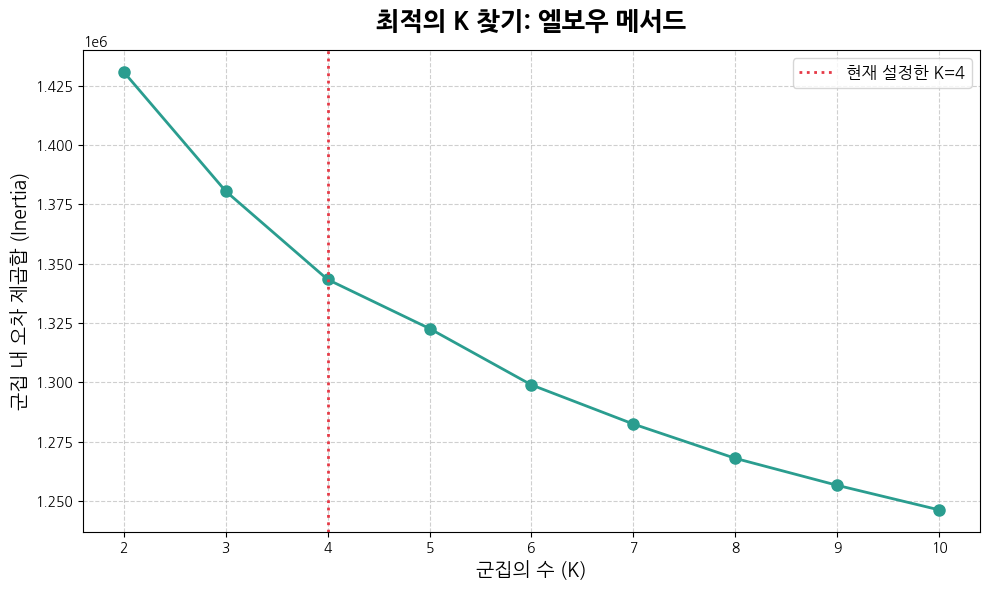

In [12]:
from sklearn.cluster import KMeans

print("🔍 최적의 군집 수(K)를 찾기 위한 엘보우(Elbow) 분석 시작...")
print("(768차원의 방대한 데이터로 여러 번 군집화를 시도하므로 1~3분 정도 소요됩니다!)")

# K를 2부터 10까지 테스트
k_range = range(2, 11)
inertias = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(embeddings)
    inertias.append(kmeans.inertia_) # inertia_: 군집 내 오차 제곱합(SSE)

print("✅ 분석 완료! 엘보우 그래프를 그립니다.")

# 엘보우 그래프 시각화
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, marker='o', linestyle='-', color='#2A9D8F', linewidth=2, markersize=8)

# 차트 디자인
plt.title('최적의 K 찾기: 엘보우 메서드', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('군집의 수 (K)', fontsize=14)
plt.ylabel('군집 내 오차 제곱합 (Inertia)', fontsize=14)
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)

# 우리가 설정했던 K=4 지점에 강조 표시
plt.axvline(x=4, color='#E63946', linestyle=':', linewidth=2, label='현재 설정한 K=4')
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

## 실루엣 스코어 & 데이비스-볼딘 지수

📏 정밀 군집 평가 지표 계산 중 (1~2분 소요될 수 있습니다)...


✅ 계산 완료! 비교 그래프를 그립니다.


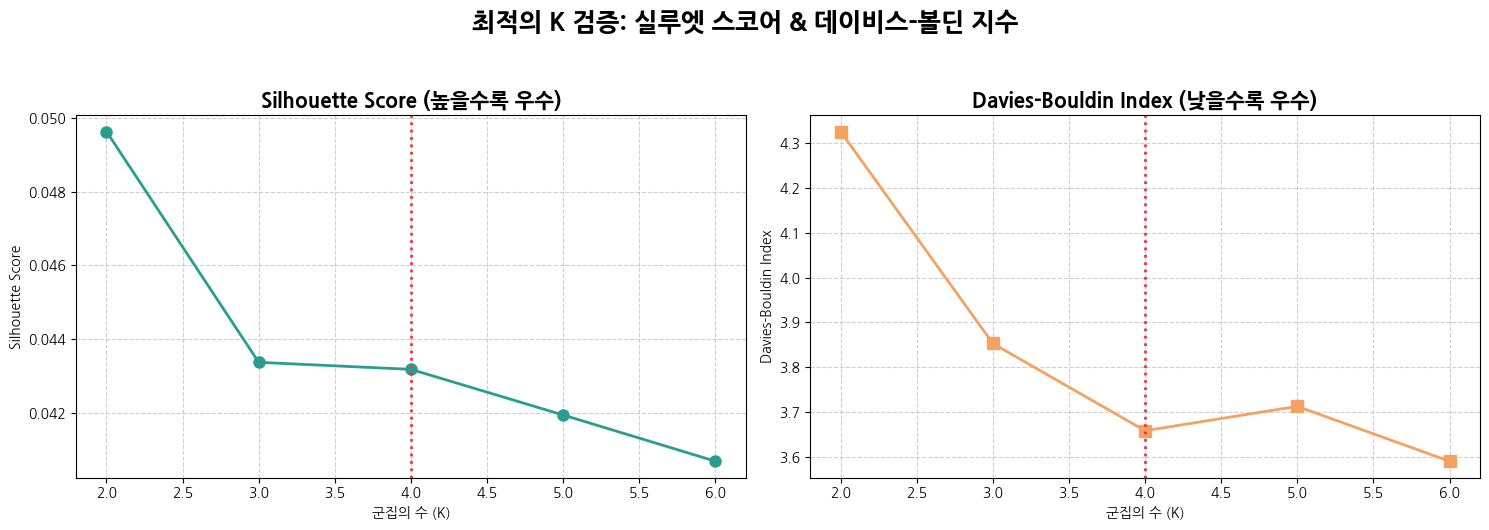

In [13]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import KMeans

print("📏 정밀 군집 평가 지표 계산 중 (1~2분 소요될 수 있습니다)...")

k_range = range(2, 7)
silhouette_scores = []
db_scores = []

for k in k_range:
    # 군집화 진행
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(embeddings)
    
    # 1. 실루엣 스코어 (높을수록 좋음)
    sil_score = silhouette_score(embeddings, labels)
    silhouette_scores.append(sil_score)
    
    # 2. 데이비스-볼딘 지수 (낮을수록 좋음)
    db_score = davies_bouldin_score(embeddings, labels)
    db_scores.append(db_score)

print("✅ 계산 완료! 비교 그래프를 그립니다.")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# [왼쪽] 실루엣 스코어 그래프 (높을수록 좋음)
axes[0].plot(k_range, silhouette_scores, marker='o', color='#2A9D8F', linewidth=2, markersize=8)
axes[0].set_title('Silhouette Score (높을수록 우수)', fontsize=15, fontweight='bold')
axes[0].set_xlabel('군집의 수 (K)')
axes[0].set_ylabel('Silhouette Score')
axes[0].axvline(x=4, color='#E63946', linestyle=':', linewidth=2) # K=4 강조
axes[0].grid(True, linestyle='--', alpha=0.6)

# [오른쪽] 데이비스-볼딘 지수 그래프 (낮을수록 좋음)
axes[1].plot(k_range, db_scores, marker='s', color='#F4A261', linewidth=2, markersize=8)
axes[1].set_title('Davies-Bouldin Index (낮을수록 우수)', fontsize=15, fontweight='bold')
axes[1].set_xlabel('군집의 수 (K)')
axes[1].set_ylabel('Davies-Bouldin Index')
axes[1].axvline(x=4, color='#E63946', linestyle=':', linewidth=2) # K=4 강조
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.suptitle('최적의 K 검증: 실루엣 스코어 & 데이비스-볼딘 지수', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# 군집별 핵심 키워드 추출 (Keyword Extraction)

## Kiwi 형태소 분석기

In [14]:
# Kiwi 설치
!pip install kiwipiepy

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from kiwipiepy import Kiwi

print("🥝 Kiwi 형태소 분석기 로딩 (명사 + 형용사 + 동사 추출 모드)...")
kiwi = Kiwi()

def extract_core_words_clean(text):
    if not isinstance(text, str) or not text.strip():
        return []
        
    tokens = kiwi.tokenize(text)
    result = []
    
    for token in tokens:
        # 1. 명사 추출
        if token.tag.startswith('N'):
            result.append(token.form)
        
        # 2. 형용사/동사 추출
        elif token.tag in ['VA', 'VV']:
            result.append(token.lemma)
            
    # 3. 💡 초강력 불용어(Stopwords) 필터링
    stop_words = [
        # 무의미한 명사들
        '것', '수', '이', '거', '저', '요', '때', '좀', '옷', '구매', '생각', '정도', '마음', '제', '나', '주문',
        '진짜', '너무', '그냥', '조금', '약간', '듯', '편', '때문', '건', '많이','상품', '느낌', '사용', '정말',
        # 무의미하거나 너무 뻔한 동사/형용사들
        '하다', '있다', '없다', '같다', '되다', '않다', '좋다', '사다', '입다', '보다', 
        '들다', '맞다', '이다', '아니다', '가다', '오다', '나오다', '주다', '받다', '모르다',
        # 추가 키워드
        '예쁘다', '이쁘다', '좋다', '만족', '괜찮다', '추천',
        '사이즈', '편하다', '색', '색상', '기본', '하나', '이번', 
        '작년', '이거', '여기저기', '요즘', '어디', '최고', '처음', '사진', '리뷰'
    ]
    
    # 한 글자짜리 단어 중에서도 의미 없는 것들(예: '핏', '품', '색'은 살리고 나머진 제거)을 걸러내는 로직 추가
    final_words = []
    for w in result:
        if w not in stop_words:
            # 1글자인데 우리가 원하는 핵심 패션 단어가 아니면 버림
            if len(w) == 1 and w not in ['핏', '품', '색', '질', '목', '팔', '통']:
                continue
            final_words.append(w)
            
    return final_words
print("🥝 Kiwi 형태소 분석기 완료")

🥝 Kiwi 형태소 분석기 로딩 (명사 + 형용사 + 동사 추출 모드)...
🥝 Kiwi 형태소 분석기 완료


## TF-IDF

In [16]:
print("📊 TF-IDF 기반 군집별 Top 20 핵심 키워드 추출 시작...")

vectorizer = TfidfVectorizer(tokenizer=extract_core_words_clean, max_features=500)
top_keywords_dict = {}

for i in range(4):
    cluster_texts = df_clean[df_clean['cluster'] == i]['content_clean']
    
    if not cluster_texts.empty:
        tfidf_matrix = vectorizer.fit_transform(cluster_texts)
        words = vectorizer.get_feature_names_out()
        word_scores = np.array(tfidf_matrix.sum(axis=0)).flatten()
        top_indices = word_scores.argsort()[-20:][::-1]
        top_keywords_dict[f'Cluster {i}'] = [words[idx] for idx in top_indices]

df_top_keywords = pd.DataFrame(top_keywords_dict)
df_top_keywords.index = [f'Rank {i}' for i in range(1, 21)]

print("\n✨ [명사+형용사+동사] 군집별 핵심 키워드 Top 20 ✨")
display(df_top_keywords)

📊 TF-IDF 기반 군집별 Top 20 핵심 키워드 추출 시작...


c:\Users\master\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



✨ [명사+형용사+동사] 군집별 핵심 키워드 Top 20 ✨


,Cluster 0,Cluster 1,Cluster 2,Cluster 3
Rank 1,핏,여름,핏,핏
Rank 2,가격,핏,크다,재질
Rank 3,매장,얇다,허리,배송
Rank 4,크다,이너,길다,가격
Rank 5,블랙,재질,바지,빠르다
Rank 6,구입,소재,길이,어울리다
Rank 7,재질,다니다,작다,길이
Rank 8,가성비,두께,기장,디자인
Rank 9,세일,가을,보이다,가성비
Rank 10,신사,시원하다,재질,바지


## 워드클라우드

☁️ 판매금액순 리뷰 워드클라우드 생성 중 (태블로 스타일 타원형 적용)...


c:\Users\master\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


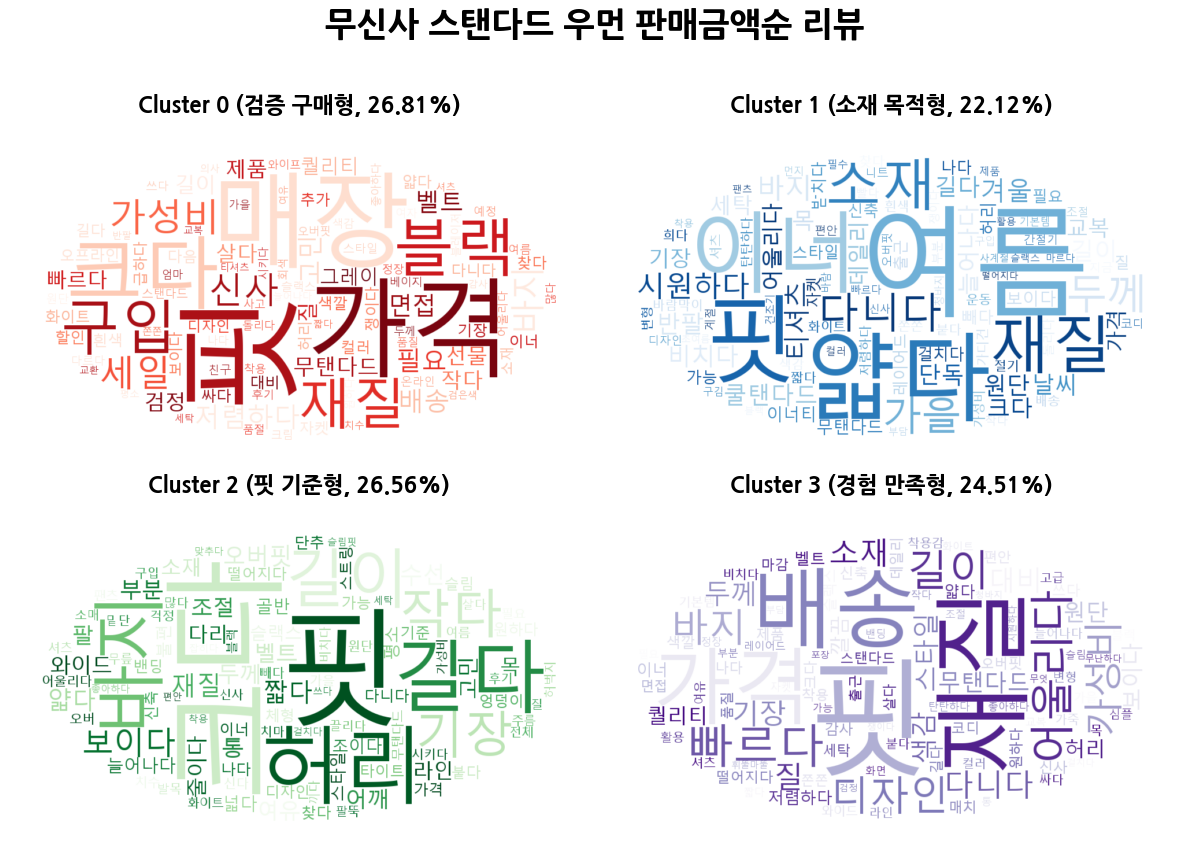

In [17]:
from wordcloud import WordCloud
from PIL import Image, ImageDraw

print("☁️ 판매금액순 리뷰 워드클라우드 생성 중 (태블로 스타일 타원형 적용)...")

# 윈도우 기본 한글 폰트 경로 (워드클라우드는 별도 폰트 지정이 필수)
font_path = 'C:/Windows/Fonts/malgun.ttf'

# ==========================================
# 💡 [핵심 추가] 둥근 타원형 마스크(틀) 생성하기
# ==========================================
# 1. 가로 1000, 세로 600짜리 하얀색(255) 도화지를 만듭니다.
# 'L'은 그레이스케일 모드를 의미합니다.
mask_image = Image.new('L', (1000, 600), 255)
draw = ImageDraw.Draw(mask_image)

# 2. 도화지 가운데에 까만색(0) 타원을 그립니다. 
# (워드클라우드는 하얀색 영역은 무시하고, 까만색 영역에만 글자를 채워 넣습니다!)
# 여백(50)을 약간 두고 타원을 꽉 차게 그립니다.
draw.ellipse((50, 50, 950, 550), fill=0)

# 3. 이 그림을 넘파이 배열(숫자)로 변환하여 마스크로 준비합니다.
oval_mask = np.array(mask_image)
# ==========================================

# 1. 2x2 도화지(Figure) 세팅
# 기존 12, 9 크기는 유지
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten() # 2차원 배열을 1차원을 펴서 다루기 쉽게 만듭니다.

# 각 군집별 테마 색상 및 타이틀 세팅
colormaps = ['Reds', 'Blues', 'Greens', 'Purples']
cluster_titles = [
    'Cluster 0 (검증 구매형, 26.81%)', 
    'Cluster 1 (소재 목적형, 22.12%)', 
    'Cluster 2 (핏 기준형, 26.56%)', 
    'Cluster 3 (경험 만족형, 24.51%)'
]

# 메인 타이틀
plt.suptitle('무신사 스탠다드 우먼 판매금액순 리뷰', fontsize=24, fontweight='bold', y=0.98)

for i in range(4):
    # 각 군집 텍스트 추출 (df_clean 사용)
    cluster_texts = df_clean[df_clean['cluster'] == i]['content_clean']
    
    if not cluster_texts.empty:
        # TF-IDF 점수 다시 계산 (단어의 가중치를 워드클라우드 크기로 쓰기 위함)
        tfidf_matrix = vectorizer.fit_transform(cluster_texts)
        words = vectorizer.get_feature_names_out()
        word_scores = np.array(tfidf_matrix.sum(axis=0)).flatten()
        
        # 핵심: 단어와 TF-IDF 점수를 딕셔너리로 묶어줍니다.
        word_score_dict = dict(zip(words, word_scores))
        
        # 💡 [핵심 수정] WordCloud 설정 변경
        wc = WordCloud(
            font_path=font_path,
            width=1000, height=600, # 마스크와 동일한 비율 권장
            background_color='white',
            colormap=colormaps[i], # 군집별로 다른 색상 적용
            mask=oval_mask,         # ✨ [핵심] 생성한 타원형 마스크 씌우기
            contour_width=0,        # ✨ [핵심] 테두리 선은 없애서 깔끔하게
            max_words=100           # 너무 자잘한 단어는 빼고 최대 100개만
        ).generate_from_frequencies(word_score_dict)
        
        # 서브플롯에 그리기
        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].set_title(cluster_titles[i], fontsize=16, fontweight='bold', pad=10)
        axes[i].axis('off') # 지저분한 눈금선 제거

# 여백 깔끔하게 정리 (메인 타이틀과 겹치지 않게 rect 설정)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# UMAP 차원 축소 및 시각화

🌌 768차원의 리뷰 데이터를 2차원 지도로 압축하는 중입니다...


c:\Users\master\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✅ 차원 축소 완료! 매혹적인 우주 지도를 그립니다.


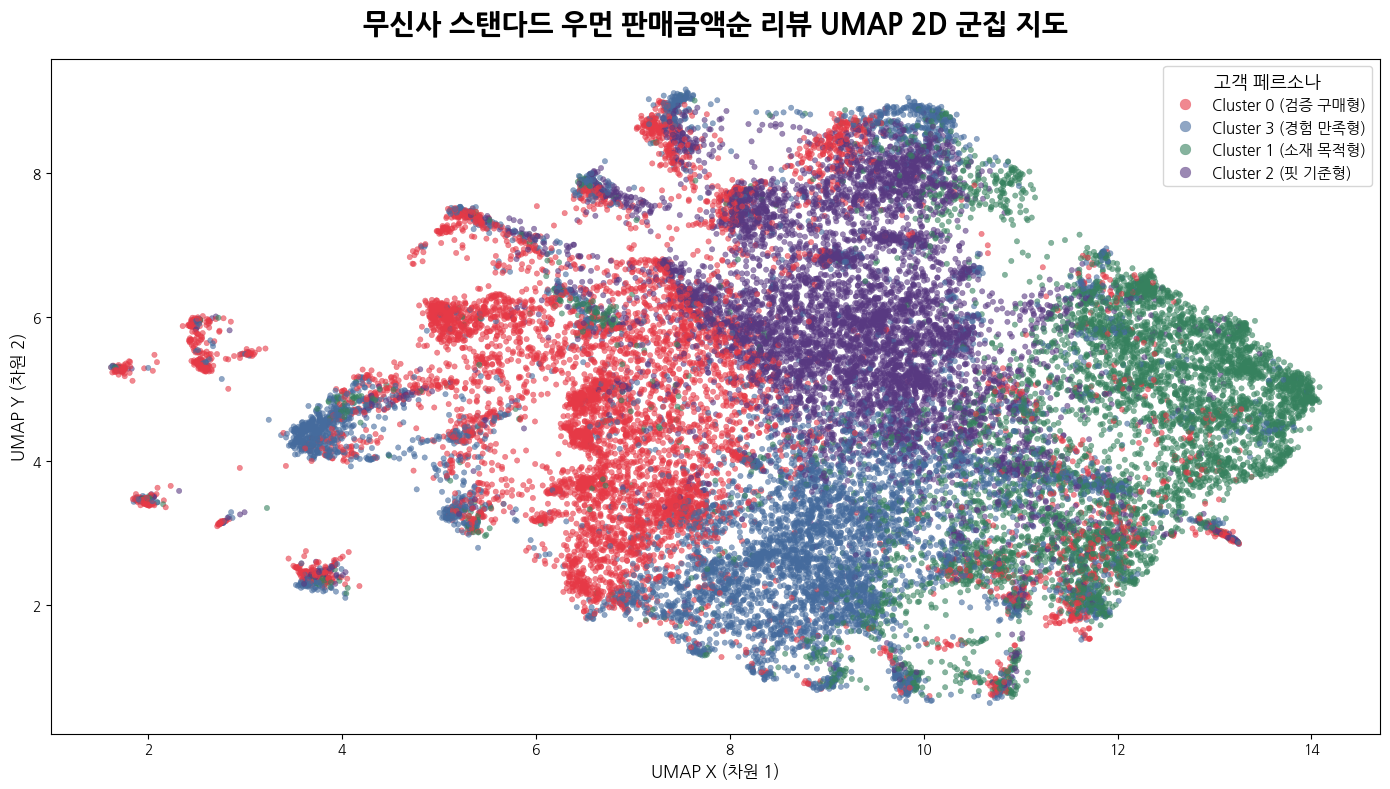

In [20]:
# !pip install umap-learn seaborn

import umap.umap_ as umap
import koreanize_matplotlib

print("🌌 768차원의 리뷰 데이터를 2차원 지도로 압축하는 중입니다...")

# 1. UMAP 모델 설정 및 차원 축소 진행
# n_neighbors: 지도를 그릴 때 주변 이웃을 몇 명이나 고려할 것인가 (군집의 조밀도)
# min_dist: 점들 사이의 최소 거리 (너무 뭉치지 않게)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
umap_result = reducer.fit_transform(embeddings)

# 2. 압축된 2D 좌표(x, y)를 데이터프레임에 추가
df_clean['umap_x'] = umap_result[:, 0]
df_clean['umap_y'] = umap_result[:, 1]

print("✅ 차원 축소 완료! 매혹적인 우주 지도를 그립니다.")

# 3. 이름표
cluster_names = {
    0: 'Cluster 0 (검증 구매형)',
    1: 'Cluster 1 (소재 목적형)',
    2: 'Cluster 2 (핏 기준형)',
    3: 'Cluster 3 (경험 만족형)'
}

# 숫자로 된 cluster 컬럼을 이름표로 매핑한 새 컬럼 생성
df_clean['persona'] = df_clean['cluster'].map(cluster_names)

# 4. Seaborn을 활용한 고퀄리티 산점도(Scatter Plot) 시각화
plt.figure(figsize=(14, 8))

# 테마 색상 지정 (워드클라우드와 비슷한 느낌으로!)
palette = ["#E63946", "#456B9D", "#36815E", "#583981"]

sns.scatterplot(
    x='umap_x', 
    y='umap_y', 
    hue='persona', 
    palette=palette,
    data=df_clean, 
    s=15,          # 점 크기
    alpha=0.6,     # 투명도 (겹치는 부분 확인용)
    edgecolor=None # 점 테두리 제거 (더 깔끔하게)
)

# 차트 꾸미기
plt.title('무신사 스탠다드 우먼 판매금액순 리뷰 UMAP 2D 군집 지도', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('UMAP X (차원 1)', fontsize=12)
plt.ylabel('UMAP Y (차원 2)', fontsize=12)

# 범례(Legend) 디자인 수정
plt.legend(title='고객 페르소나', title_fontsize='13', fontsize='11', loc='best', markerscale=2)

plt.tight_layout()
plt.show()

# 군집별 긍정/부정(감성분석) 비율 시각화

📊 판매금액순 리뷰: 페르소나별 감성(불만) 비율 교차 분석 중...

[👀 판매순 페르소나별 긍정/부정 비율(%)]


sentiment_score,0,1
persona,,
Cluster 0 (검증 구매형),3.7,96.3
Cluster 1 (소재 목적형),4.2,95.8
Cluster 2 (핏 기준형),10.7,89.3
Cluster 3 (경험 만족형),0.4,99.6


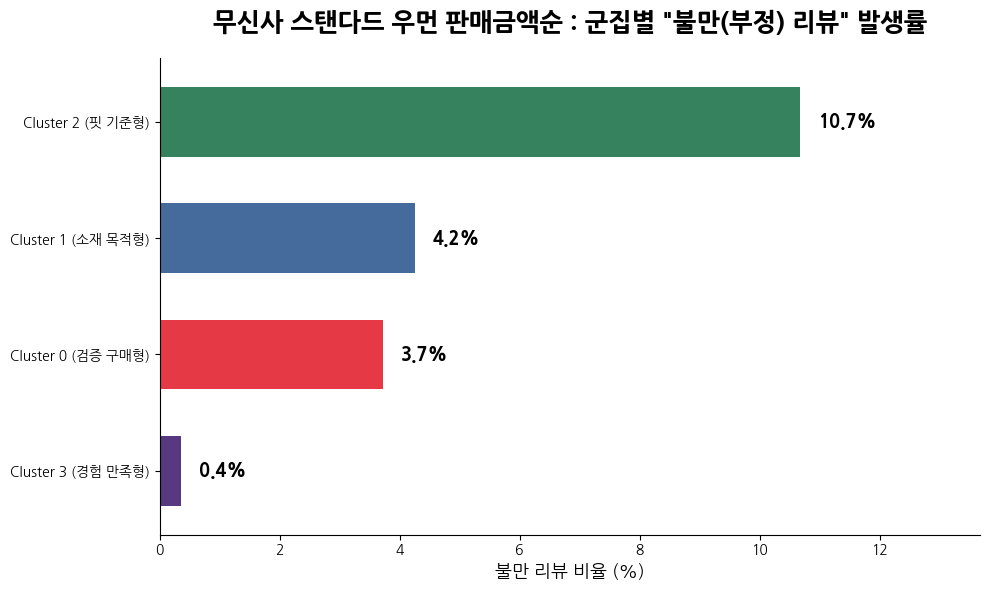

In [21]:
print("📊 판매금액순 리뷰: 페르소나별 감성(불만) 비율 교차 분석 중...")

# 1. 💡 [판매금액순] 데이터프레임에 맞는 페르소나 이름 매핑
cluster_names = {
    0: 'Cluster 0 (검증 구매형)',
    1: 'Cluster 1 (소재 목적형)',
    2: 'Cluster 2 (핏 기준형)',
    3: 'Cluster 3 (경험 만족형)'
}
df_clean['persona'] = df_clean['cluster'].map(cluster_names)

# 2. 페르소나별 긍정(1)/부정(0) 리뷰 개수 집계
sentiment_counts = df_clean.groupby(['persona', 'sentiment_score']).size().unstack(fill_value=0)

# 3. 비율(%) 변환
sentiment_ratio = sentiment_counts.div(sentiment_counts.sum(axis=1), axis=0) * 100

# 4. 수치 확인
print("\n[👀 판매순 페르소나별 긍정/부정 비율(%)]")
display(sentiment_ratio.round(1))

# 5. 불만 비율만 추출 및 정렬
negative_ratio = sentiment_ratio[0].sort_values(ascending=True)

# ==========================================
# 💡 [핵심] 페르소나 이름별 색상 고정 매핑
# ==========================================
# 판매순 군집 번호와 매칭되는 상징 컬러를 지정합니다.
color_map = {
    'Cluster 0 (검증 구매형)': '#E63946',    # 빨강
    'Cluster 1 (소재 목적형)': '#456B9D',  # 파랑
    'Cluster 2 (핏 기준형)': '#36815E', # 초록
    'Cluster 3 (경험 만족형)': '#583981' # 보라
}

# 정렬된 막대 순서에 맞춰서 색상 리스트를 생성합니다.
ordered_colors = [color_map[name] for name in negative_ratio.index]

# 6. 시각화
plt.figure(figsize=(10, 6))
ax = negative_ratio.plot(kind='barh', color=ordered_colors, width=0.6)

# 디자인 및 타이틀
plt.title('무신사 스탠다드 우먼 판매금액순 : 군집별 "불만(부정) 리뷰" 발생률', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('불만 리뷰 비율 (%)', fontsize=13)
plt.ylabel('') 

# 막대 끝에 숫자 달기
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.3, 
             p.get_y() + p.get_height()/2, 
             f'{width:.1f}%', 
             ha='left', va='center', fontsize=13, fontweight='bold', color='black')

plt.xlim(0, negative_ratio.max() + 3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()